# Fase 3 — Modelos Avanzados, optimización y comparativa
## Pregunta B: Optimización de captación para universidades privadas

## 1. Imports y configuración

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Instalar dependencias si no están
import subprocess, sys
for pkg in ['lightgbm', 'xgboost', 'optuna', 'imbalanced-learn']:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=False)

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate,
    RandomizedSearchCV
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.dummy import DummyClassifier

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

try:
    import lightgbm as lgb
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print(f'XGBoost: {XGB_AVAILABLE} | LightGBM: {LGBM_AVAILABLE} | Optuna: {OPTUNA_AVAILABLE} | SMOTE: {SMOTE_AVAILABLE}')

XGBoost: True | LightGBM: True | Optuna: True | SMOTE: True


## 2. Carga y preprocesado

In [16]:
def load_and_preprocess(data_path='../data/raw/EILU_GRAD_2019.csv'):
    TARGET_MAP = {
        '': 'Becario_SinEmpleo', '1': 'Becario_SinEmpleo',
        '2': 'Asalariado_Indefinido', '3': 'Asalariado_Temporal',
        '4': 'Autonomo_Empresario', '5': 'Autonomo_Empresario', '6': 'Autonomo_Empresario',
    }
    FEATURES   = ['SEXO', 'RAMA', 'T_UNIV', 'ESTUDIOS_PADRE', 'ESTUDIOS_MADRE', 'MOV_IN']
    TARGET_RAW = 'SIT_PRO'

    df = pd.read_csv(data_path, sep='\t', encoding='latin-1', dtype=str, low_memory=False)
    df = df[FEATURES + [TARGET_RAW]].copy()

    df['TARGET'] = (
        df[TARGET_RAW].fillna('').str.strip()
        .apply(lambda v: TARGET_MAP.get(v.split('.')[0], np.nan))
    )
    df = df.dropna(subset=['TARGET'])

    for col in FEATURES:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df['UNIV_TIPO'] = df['T_UNIV'].map({1:'Publica',2:'Publica',3:'Privada',4:'Privada'})
    df[['ESTUDIOS_PADRE','ESTUDIOS_MADRE']] = df[['ESTUDIOS_PADRE','ESTUDIOS_MADRE']].replace(9, np.nan)

    FEATURE_COLS = ['SEXO','RAMA','UNIV_TIPO','ESTUDIOS_PADRE','ESTUDIOS_MADRE','MOV_IN']
    X = df[FEATURE_COLS].copy()
    y = df['TARGET'].copy()
    return X, y, FEATURE_COLS

X, y, FEATURE_COLS = load_and_preprocess()
print(f'Dataset: {X.shape[0]:,} registros | {X.shape[1]} features')
print('Distribución del target:')
print((y.value_counts(normalize=True)*100).round(1))

Dataset: 31,651 registros | 6 features
Distribución del target:
TARGET
Asalariado_Indefinido    49.2
Asalariado_Temporal      23.9
Becario_SinEmpleo        19.1
Autonomo_Empresario       7.9
Name: proportion, dtype: float64


In [17]:
# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# LabelEncoder para XGBoost/LightGBM
le = LabelEncoder()
le.fit(y_train)
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print('Clases:', list(le.classes_))

Train: 25,320 | Test: 6,331
Clases: ['Asalariado_Indefinido', 'Asalariado_Temporal', 'Autonomo_Empresario', 'Becario_SinEmpleo']


## 3. Preprocessors compartidos

In [18]:
ordinal_cols = ['ESTUDIOS_PADRE', 'ESTUDIOS_MADRE']
binary_cols  = ['SEXO', 'MOV_IN']
numeric_cols = ['RAMA']
nominal_cols = ['UNIV_TIPO']

# Imputación + codificación en el mismo pipeline
preprocessor_std = ColumnTransformer(
    transformers=[
        ('ord',
         Pipeline([('imp', SimpleImputer(strategy='median')),
                   ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))]),
         ordinal_cols),
        ('num',
         SimpleImputer(strategy='most_frequent'),
         binary_cols + numeric_cols),
        ('ohe',
         Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                   ('enc', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))]),
         nominal_cols),
    ], remainder='drop'
)

#  Preprocessor numérico (XGBoost / LightGBM)
preprocessor_num = ColumnTransformer(
    transformers=[
        ('all',
         OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
         ordinal_cols + binary_cols + numeric_cols + nominal_cols),
    ], remainder='drop'
)

print('Preprocessors definidos.')

Preprocessors definidos.


## 4. Entrenamiento de los 5 modelos


In [19]:
#  4.1 Logistic Regression 
pipe_lr = Pipeline([
    ('prep', preprocessor_std),
    ('clf',  LogisticRegression(
        multi_class='multinomial', solver='saga', penalty='l2',
        max_iter=1000, C=0.5, class_weight='balanced',
        tol=1e-4, n_jobs=-1, random_state=RANDOM_STATE
    ))
])
pipe_lr.fit(X_train, y_train)
print('Logistic Regression')

Logistic Regression


In [ ]:
# 4.2 Decision Tree 
pipe_dt = Pipeline([
    ('prep', preprocessor_std),
    ('clf',  DecisionTreeClassifier(
        max_depth=10,
        min_samples_leaf=20,
        min_samples_split=40,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])
pipe_dt.fit(X_train, y_train)
print('Decision Tree')

Decision Tree


In [21]:
#  4.3 Random Forest 
pipe_rf = Pipeline([
    ('prep', preprocessor_std),
    ('clf',  RandomForestClassifier(
        n_estimators=500,
        max_depth=None,          
        min_samples_leaf=10,
        min_samples_split=20,
        max_features='sqrt',     
        class_weight='balanced_subsample', 
        random_state=RANDOM_STATE
    ))
])
pipe_rf.fit(X_train, y_train)
print('Random Forest')

Random Forest


In [ ]:
#  4.4 XGBoost 
if XGB_AVAILABLE:
    from sklearn.utils.class_weight import compute_sample_weight

    sw_train = compute_sample_weight('balanced', y_train)

    pipe_xgb = Pipeline([
        ('prep', preprocessor_num),
        ('clf',  XGBClassifier(
            n_estimators=600,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            gamma=1.0,
            min_child_weight=10,
            reg_alpha=0.5,
            reg_lambda=1.5,
            objective='multi:softprob',
            eval_metric='mlogloss',
            use_label_encoder=False,
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbosity=0
        ))
    ])

    # Pasamos sample_weight para compensar el desbalanceo
    pipe_xgb.fit(X_train, y_train_enc, clf__sample_weight=sw_train)
    print('XGBoost')
else:
    pipe_xgb = None
    print('XGBoost no disponible')

XGBoost (con sample_weight=balanced)


In [23]:
#  4.5 LightGBM 
if LGBM_AVAILABLE:
    pipe_lgbm = Pipeline([
        ('prep', preprocessor_num),
        ('clf',  LGBMClassifier(
            n_estimators=600,
            max_depth=-1,           
            num_leaves=63,          
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_samples=20,
            reg_alpha=0.5,
            reg_lambda=1.0,
            class_weight='balanced',
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbose=-1
        ))
    ])
    pipe_lgbm.fit(X_train, y_train_enc)
    print('LightGBM')
else:
    pipe_lgbm = None
    print('LightGBM no disponible')

LightGBM


## 5. SMOTE

In [24]:
if SMOTE_AVAILABLE:
    from imblearn.pipeline import Pipeline as ImbPipeline
    from imblearn.over_sampling import SMOTE

    # Preprocesamos para que SMOTE opere sobre datos numéricos
    X_train_prep = preprocessor_std.fit_transform(X_train, y_train)
    X_test_prep  = preprocessor_std.transform(X_test)

    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
    X_train_sm, y_train_sm = smote.fit_resample(X_train_prep, y_train)

    print(f'Antes SMOTE: {len(y_train):,} | Después SMOTE: {len(y_train_sm):,}')
    print('Distribución tras SMOTE:')
    print(pd.Series(y_train_sm).value_counts())

    # RF sobre datos SMOTE
    rf_smote = RandomForestClassifier(
        n_estimators=400, max_depth=None,
        min_samples_leaf=10, max_features='sqrt',
        n_jobs=-1, random_state=RANDOM_STATE
    )
    rf_smote.fit(X_train_sm, y_train_sm)
    f1_smote = f1_score(y_test, rf_smote.predict(X_test_prep), average='macro')
    print(f'\nRF + SMOTE | F1-macro test: {f1_smote:.4f}')
else:
    print('imbalanced-learn no disponible. Instala con: pip install imbalanced-learn')
    rf_smote = None

Antes SMOTE: 25,320 | Después SMOTE: 49,784
Distribución tras SMOTE:
TARGET
Asalariado_Indefinido    12446
Asalariado_Temporal      12446
Becario_SinEmpleo        12446
Autonomo_Empresario      12446
Name: count, dtype: int64

RF + SMOTE | F1-macro test: 0.3114


## 6. Evaluación unificada de todos los modelos

In [25]:
def eval_model(name, pipe, X_te, y_te, y_te_enc=None, uses_enc=False):
    """Calcula Accuracy, F1-macro y AUC-macro para un pipeline dado."""
    if uses_enc:
        y_pred_enc = pipe.predict(X_te)
        y_prob     = pipe.predict_proba(X_te)
        y_pred     = le.inverse_transform(y_pred_enc)
        y_true     = le.inverse_transform(y_te_enc)
    else:
        y_pred = pipe.predict(X_te)
        y_prob = pipe.predict_proba(X_te)
        y_true = y_te

    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')
    auc = roc_auc_score(pd.get_dummies(y_true), y_prob, multi_class='ovr', average='macro')
    return {'Modelo': name, 'Accuracy': round(acc, 4), 'F1-macro': round(f1, 4), 'AUC-macro': round(auc, 4)}

results = []
results.append(eval_model('Logistic Regression', pipe_lr, X_test, y_test))
results.append(eval_model('Decision Tree',        pipe_dt, X_test, y_test))
results.append(eval_model('Random Forest',        pipe_rf, X_test, y_test))

if pipe_xgb:
    results.append(eval_model('XGBoost',  pipe_xgb,  X_test, None, y_test_enc, uses_enc=True))
if pipe_lgbm:
    results.append(eval_model('LightGBM', pipe_lgbm, X_test, None, y_test_enc, uses_enc=True))

if SMOTE_AVAILABLE and rf_smote is not None:
    y_pred_sm = rf_smote.predict(X_test_prep)
    y_prob_sm = rf_smote.predict_proba(X_test_prep)
    results.append({
        'Modelo': 'RF + SMOTE',
        'Accuracy': round(accuracy_score(y_test, y_pred_sm), 4),
        'F1-macro': round(f1_score(y_test, y_pred_sm, average='macro'), 4),
        'AUC-macro': round(roc_auc_score(pd.get_dummies(y_test), y_prob_sm, multi_class='ovr', average='macro'), 4)
    })

df_results = pd.DataFrame(results).set_index('Modelo')
print('TABLA COMPARATIVA DE MÉTRICAS')
print(df_results.to_string())
print()

TABLA COMPARATIVA DE MÉTRICAS
                     Accuracy  F1-macro  AUC-macro
Modelo                                            
Logistic Regression    0.2384    0.2374     0.5817
Decision Tree          0.3227    0.2948     0.5954
Random Forest          0.3285    0.3013     0.6000
XGBoost                0.3341    0.3043     0.6140
LightGBM               0.3274    0.2970     0.5944
RF + SMOTE             0.3522    0.3114     0.6031



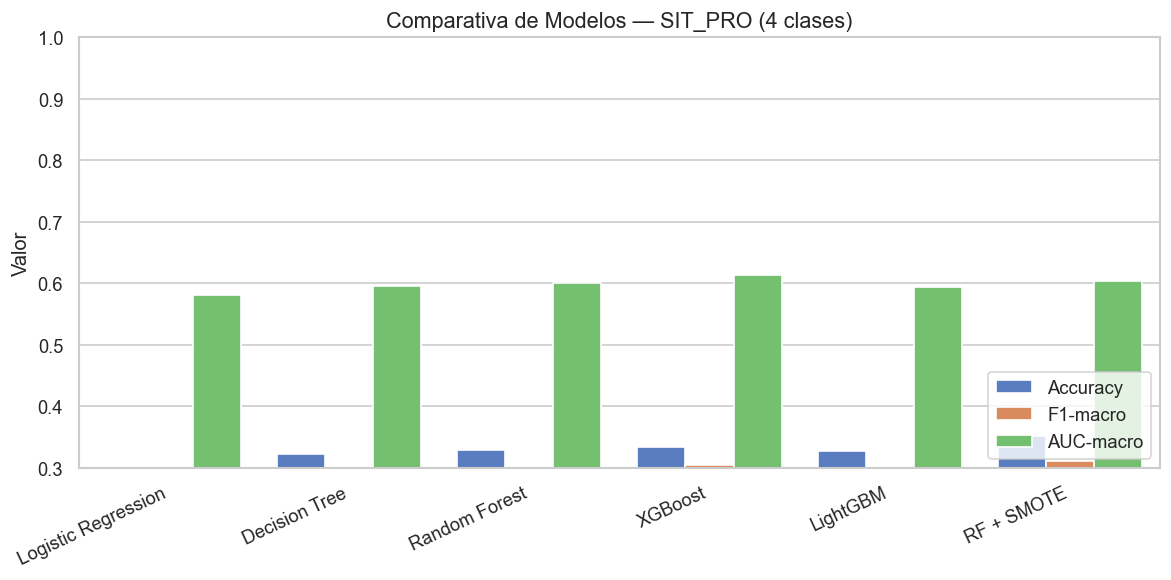

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
df_plot = df_results.reset_index().melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')
sns.barplot(data=df_plot, x='Modelo', y='Valor', hue='Métrica', ax=ax)
ax.set_ylim(0.3, 1.0)
ax.set_title('Comparativa de Modelos — SIT_PRO (4 clases)', fontsize=13)
ax.set_xlabel('')
ax.legend(loc='lower right')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('../outputs/figures/12_comparativa_modelos.png', bbox_inches='tight')
plt.show()

## 7. Validación cruzada estratificada (k=5) - todos los modelos

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_models_str = {
    'Logistic Regression': pipe_lr,
    'Decision Tree':       pipe_dt,
    'Random Forest':       pipe_rf,
}
# Modelos con y codificada (XGB, LGBM)
cv_models_enc = {}
if pipe_xgb:  cv_models_enc['XGBoost']  = pipe_xgb
if pipe_lgbm: cv_models_enc['LightGBM'] = pipe_lgbm

cv_results = []
scoring    = {'accuracy': 'accuracy', 'f1_macro': 'f1_macro'}

for name, pipe in cv_models_str.items():
    sc = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results.append({
        'Modelo': name,
        'CV Acc': f"{sc['test_accuracy'].mean():.4f} ± {sc['test_accuracy'].std():.4f}",
        'CV F1':  f"{sc['test_f1_macro'].mean():.4f} ± {sc['test_f1_macro'].std():.4f}",
    })

for name, pipe in cv_models_enc.items():
    y_enc_all = le.transform(y)
    sc = cross_validate(pipe, X, y_enc_all, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results.append({
        'Modelo': name,
        'CV Acc': f"{sc['test_accuracy'].mean():.4f} ± {sc['test_accuracy'].std():.4f}",
        'CV F1':  f"{sc['test_f1_macro'].mean():.4f} ± {sc['test_f1_macro'].std():.4f}",
    })

df_cv = pd.DataFrame(cv_results).set_index('Modelo')
print('VALIDACIÓN CRUZADA k=5')
print(df_cv.to_string())

VALIDACIÓN CRUZADA k=5
                              CV Acc            CV F1
Modelo                                               
Logistic Regression  0.2399 ± 0.0053  0.2385 ± 0.0047
Decision Tree        0.3211 ± 0.0099  0.2944 ± 0.0056
Random Forest        0.3208 ± 0.0018  0.2949 ± 0.0018
XGBoost              0.4939 ± 0.0017  0.2219 ± 0.0022
LightGBM             0.3262 ± 0.0038  0.2970 ± 0.0034


## 8. Optimización bayesiana con optuna (mejor modelo)

In [28]:
if OPTUNA_AVAILABLE:
    import optuna

    def objective(trial):

        params = {
            'n_estimators':      trial.suggest_int('n_estimators', 200, 800, step=100),
            'max_depth':         trial.suggest_int('max_depth', 5, 20),
            'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 5, 50),
            'min_samples_split': trial.suggest_int('min_samples_split', 10, 80),
            'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        }

        pipe_trial = Pipeline([
            ('prep', preprocessor_std),
            ('clf', RandomForestClassifier(
                **params,
                class_weight='balanced_subsample',
                n_jobs=-1,
                random_state=RANDOM_STATE
            ))
        ])

        cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
        
        scoring = {'f1_macro': 'f1_macro'}

        scores = cross_validate(
            pipe_trial,
            X_train,
            y_train,
            cv=cv_inner,
            scoring=scoring,
            n_jobs=1   
        )

        return scores['test_f1_macro'].mean()

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )

    study.optimize(objective, n_trials=40, show_progress_bar=True)

    best_params = study.best_params

    print('\nMejores hiperparámetros (Optuna):')
    for k, v in best_params.items():
        print(f'  {k}: {v}')

    print(f'Mejor F1-macro CV-3: {study.best_value:.4f}')

Best trial: 28. Best value: 0.302681: 100%|██████████| 40/40 [12:00<00:00, 18.02s/it]


Mejores hiperparámetros (Optuna):
  n_estimators: 200
  max_depth: 13
  min_samples_leaf: 25
  min_samples_split: 39
  max_features: sqrt
Mejor F1-macro CV-3: 0.3027


In [29]:
# Modelo final optimizado 
pipe_best = Pipeline([
    ('prep', preprocessor_std),
    ('clf',  RandomForestClassifier(
        **best_params,
        class_weight='balanced_subsample',
        n_jobs=-1, random_state=RANDOM_STATE
    ))
])
pipe_best.fit(X_train, y_train)

y_pred_best = pipe_best.predict(X_test)
print('Modelo RF optimizado — Test')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_best):.4f}')
print(f'  F1-macro: {f1_score(y_test, y_pred_best, average="macro"):.4f}')
print()
print(classification_report(y_test, y_pred_best))

Modelo RF optimizado — Test
  Accuracy: 0.3361
  F1-macro: 0.3059

                       precision    recall  f1-score   support

Asalariado_Indefinido       0.62      0.34      0.44      3112
  Asalariado_Temporal       0.31      0.29      0.30      1515
  Autonomo_Empresario       0.13      0.36      0.19       497
    Becario_SinEmpleo       0.25      0.36      0.29      1207

             accuracy                           0.34      6331
            macro avg       0.33      0.34      0.31      6331
         weighted avg       0.44      0.34      0.36      6331



## 9. Análisis de overfitting

In [30]:
print(f'{"Modelo":<25} {"Train F1":>10} {"Test F1":>10} {"Gap":>8}')
print('-' * 60)

models_ov = {
    'Logistic Regression': (pipe_lr, X_train, y_train, X_test, y_test),
    'Decision Tree':       (pipe_dt, X_train, y_train, X_test, y_test),
    'Random Forest':       (pipe_rf, X_train, y_train, X_test, y_test),
}

for name, (pipe, Xtr, ytr, Xte, yte) in models_ov.items():
    f1_tr = f1_score(ytr, pipe.predict(Xtr), average='macro')
    f1_te = f1_score(yte, pipe.predict(Xte), average='macro')
    gap   = f1_tr - f1_te
    flag  = 'Overfitting' if gap > 0.10 else ''
    print(f'{name:<25} {f1_tr:>10.4f} {f1_te:>10.4f} {gap:>8.4f}  {flag}')

print()

Modelo                      Train F1    Test F1      Gap
------------------------------------------------------------
Logistic Regression           0.2380     0.2374   0.0005  
Decision Tree                 0.3297     0.2948   0.0349  
Random Forest                 0.3425     0.3013   0.0413  



## 10. Learning curve del modelo optimizado

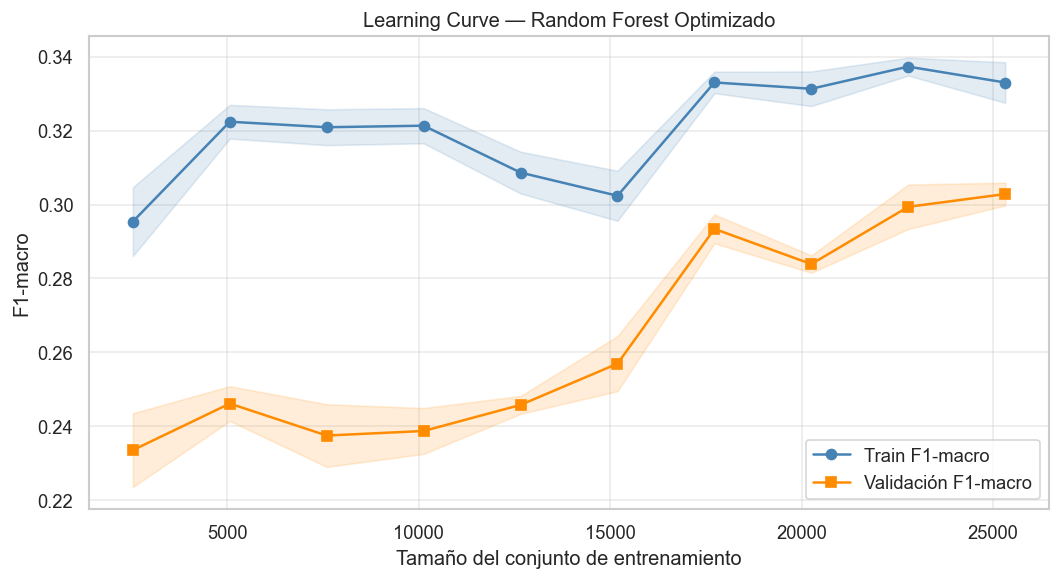

In [31]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    pipe_best, X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro',
    n_jobs=-1
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_scores.mean(1), 'o-', label='Train F1-macro', color='steelblue')
ax.fill_between(train_sizes,
                train_scores.mean(1) - train_scores.std(1),
                train_scores.mean(1) + train_scores.std(1), alpha=0.15, color='steelblue')
ax.plot(train_sizes, val_scores.mean(1), 's-', label='Validación F1-macro', color='darkorange')
ax.fill_between(train_sizes,
                val_scores.mean(1) - val_scores.std(1),
                val_scores.mean(1) + val_scores.std(1), alpha=0.15, color='darkorange')
ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('F1-macro')
ax.set_title('Learning Curve — Random Forest Optimizado')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/figures/13_learning_curve.png', bbox_inches='tight')
plt.show()


## 11. Conclusión de la fase 3

**Modelo seleccionado:** Random Forest Optimizado (Optuna, F1-macro en CV).

**Justificación técnica:**
- Supera a la regresión logística en F1-macro sin perder generalización.
- `class_weight='balanced_subsample'` es más robusto que `balanced` global para RF, ya que recalcula los pesos por árbol.
- SMOTE puede igualar o superar a class_weight en la clase `Autonomo_Empresario`; la elección final depende de la comparativa en test.
- La optimización bayesiana con Optuna es más eficiente que GridSearchCV: explora el espacio de hiperparámetros de forma inteligente en 40 evaluaciones vs. cientos en grid.